In [1]:
import intake
import intake_esm
import pandas

In [2]:
url = intake_esm.tutorial.get_url('google_cmip6')
print(url)

https://raw.githubusercontent.com/intake/intake-esm/main/tutorial-catalogs/GOOGLE-CMIP6.json


In [3]:
cat = intake.open_esm_datastore(url)
cat

,unique
activity_id,1
institution_id,2
source_id,2
experiment_id,1
member_id,72
table_id,2
variable_id,3
grid_label,2
zstore,261
dcpp_init_year,0


In [4]:
cat.unique()

activity_id                                                       [CMIP]
institution_id                                             [IPSL, CCCma]
source_id                                        [IPSL-CM6A-LR, CanESM5]
experiment_id                                               [historical]
member_id              [r2i1p1f1, r8i1p1f1, r30i1p1f1, r29i1p1f1, r3i...
table_id                                                     [Amon, Oyr]
variable_id                                                 [va, ua, o2]
grid_label                                                      [gr, gn]
zstore                 [gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histo...
dcpp_init_year                                                        []
version                         [20180803, 20190429, 20190802, 20191204]
derived_variable_id                                                   []
dtype: object

In [12]:
cat_subset = cat.search(institution_id=["IPSL"], variable_id=["va"])
cat_subset

,unique
activity_id,1
institution_id,1
source_id,1
experiment_id,1
member_id,32
table_id,1
variable_id,1
grid_label,1
zstore,32
dcpp_init_year,0


In [20]:
type(cat_subset)

intake_esm.core.esm_datastore

In [26]:
import random
has_qa = [bool(random.getrandbits(1)) for i in range(0,32)]
cat_subset.df["has_qa"] = has_qa

In [27]:
cat_subset

,unique
activity_id,1
institution_id,1
source_id,1
experiment_id,1
member_id,32
table_id,1
variable_id,1
grid_label,1
zstore,32
dcpp_init_year,0


In [6]:
dset_dict = cat_subset.to_dataset_dict(
    xarray_open_kwargs={"consolidated": True, "decode_times": True, "use_cftime": True}
)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


In [7]:
[key for key in dset_dict.keys()]

['CMIP.IPSL.IPSL-CM6A-LR.historical.Amon.gr']

In [9]:
ds = dset_dict['CMIP.IPSL.IPSL-CM6A-LR.historical.Amon.gr']
ds

<xarray.Dataset> Size: 99GB
Dimensions:         (member_id: 32, dcpp_init_year: 1, time: 1980, plev: 19,
                     lat: 143, lon: 144, axis_nbounds: 2)
Coordinates:
  * lat             (lat) float32 572B -90.0 -88.73 -87.46 ... 87.46 88.73 90.0
  * lon             (lon) float32 576B 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * plev            (plev) float32 76B 1e+05 9.25e+04 8.5e+04 ... 500.0 100.0
  * time            (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:...
    time_bounds     (time, axis_nbounds) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
  * member_id       (member_id) object 256B 'r10i1p1f1' ... 'r9i1p1f1'
  * dcpp_init_year  (dcpp_init_year) float64 8B nan
Dimensions without coordinates: axis_nbounds
Data variables:
    va              (member_id, dcpp_init_year, time, plev, lat, lon) float32 99GB dask.array<chunksize=(1, 1, 60, 19, 143, 144), meta=np.ndarray>
Attributes: (12/48)
    Conventions:                      CF-1.7 CMIP-6.2
    EXPID:                            historical
    activity_id:                      CMIP
    branch_method:                    standard
    branch_time_in_child:             0.0
    contact:                          ipsl-cmip6@listes.ipsl.fr
    ...                               ...
    intake_esm_attrs:variable_id:     va
    intake_esm_attrs:grid_label:      gr
    intake_esm_attrs:_data_format_:   zarr
    NCO:                              "4.6.0"
    variant_info:                     Restart from another point in piControl...
    intake_esm_dataset_key:           CMIP.IPSL.IPSL-CM6A-LR.historical.Amon.gr

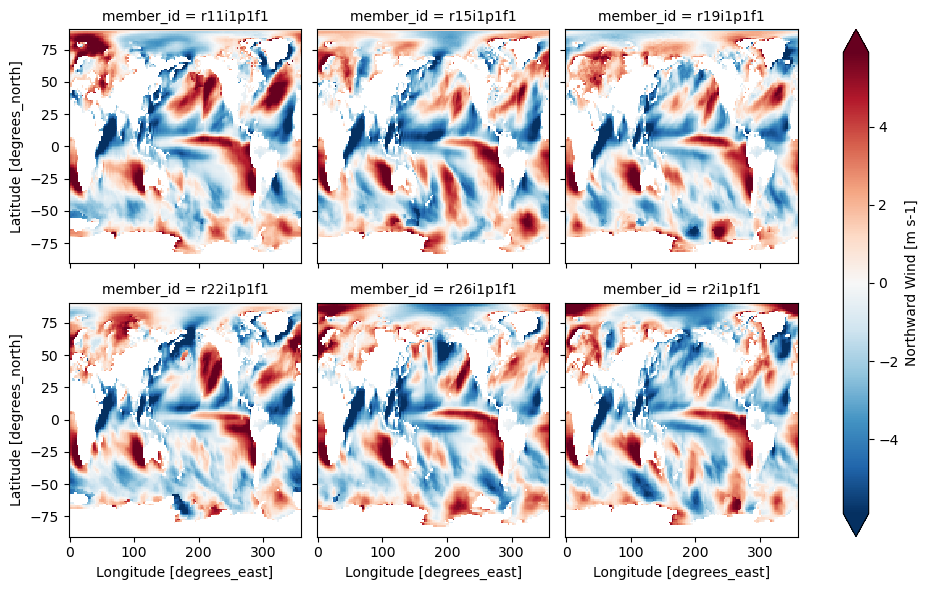

In [11]:
ds.va.isel(time=0, plev=0, member_id=range(1, 24, 4)).plot(col="member_id", col_wrap=3, robust=True)